# 2026 Player Value Prediction Report

This notebook turns the modeling work into a report someone can actually use. It trains the final models on historical player-season data, uses 2025 player information as the input, and creates 2026 projections.

The goal is not to pretend the model can perfectly rank future NFL performance. The goal is to give a clear projection, show the uncertainty around it, and make the main risks visible.


## Why This Version Is Stronger

A simple next-season value model only learns from players who appear again in the next season. That creates survivorship bias because players who disappear from the dataset are easy to ignore.

This version separates the problem into two parts:

- **Availability model:** is the player likely to have a qualifying 2026 season?
- **Value model:** if he qualifies, what value score does the model expect?

I also include prediction intervals and validation tables because a useful sports model should be honest about uncertainty.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


def find_project_root(expected_file="data/processed/player_value_scores_2016_2025.csv"):
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / expected_file).exists():
            return candidate
    raise FileNotFoundError(f"Could not find {expected_file} from {Path.cwd()}")

project_root = find_project_root()
sys.path.insert(0, str(project_root / "src"))

from prediction_report import build_2026_prediction_tables

project_root

PosixPath('/Users/kylelevesque/Desktop/nfl-player-value-analysis-1')

## Generate Prediction Tables

This cell builds the report dataset, trains the final value and availability models, predicts 2026 outcomes from 2025 inputs, and saves the report tables.

The same function is used for the CSVs, JSON payload, and Excel workbook so the outputs stay consistent.


In [2]:
outputs = build_2026_prediction_tables(project_root=project_root, save_outputs=True)

player_predictions = outputs["player_predictions"]
team_summary = outputs["team_summary"]
position_summary = outputs["position_summary"]
top_players = outputs["top_players"]
low_confidence = outputs["low_confidence"]
value_validation_by_position = outputs["value_validation_by_position"]
interval_validation = outputs["interval_validation"]
availability_metrics = outputs["availability_validation_metrics"]
model_notes = outputs["model_notes"]
output_dir = outputs["output_dir"]

print("Player predictions:", player_predictions.shape)
print("Team summary:", team_summary.shape)
print("Position summary:", position_summary.shape)
print("Value validation by position:", value_validation_by_position.shape)
print("Interval validation:", interval_validation.shape)
print("Output directory:", output_dir)


Player predictions: (505, 38)
Team summary: (32, 12)
Position summary: (4, 12)
Value validation by position: (4, 7)
Interval validation: (5, 10)
Output directory: /Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables


## Top 2026 Player Projections

`predicted_2026_value_score` is the main projection. The interval columns show an approximate central 80% range, and the qualifying probability estimates whether the player is likely to have enough 2026 data to be included again.

I read these columns together. A high projection with a wide interval or lower qualifying probability should be treated differently than a high projection with strong availability and a tighter range.


In [3]:
display(
    player_predictions[[
        "player_display_name", "position", "primary_team_2025", "games_played_2025",
        "value_score_2025", "value_score_last2_avg", "predicted_2026_value_score",
        "prediction_interval_low", "prediction_interval_high",
        "predicted_2026_qualifying_probability", "availability_risk_level",
        "predicted_2026_value_tier", "confidence_level", "prediction_driver"
    ]].head(20)
)


,player_display_name,position,primary_team_2025,games_played_2025,value_score_2025,value_score_last2_avg,predicted_2026_value_score,prediction_interval_low,prediction_interval_high,predicted_2026_qualifying_probability,availability_risk_level,predicted_2026_value_tier,confidence_level,prediction_driver
5510,Amon-Ra St. Brown,WR,DET,17,2.409907,3.460513,2.345643,1.016801,3.674484,0.949059,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
5313,George Kittle,TE,SF,11,2.530804,4.172670,2.301132,0.950520,3.651744,0.679379,Medium,Elite,Low,strong 2025 value; strong recent multi-year va...
5377,Josh Allen,QB,BUF,16,1.792685,2.668903,2.073380,0.669918,3.476841,0.924420,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
5502,Ja'Marr Chase,WR,CIN,16,1.632920,2.709680,1.922405,0.469910,3.374901,0.936335,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
5688,Puka Nacua,WR,LA,16,6.057176,2.411589,1.630139,0.196290,3.063988,0.956878,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
5577,Trey McBride,TE,ARI,17,4.422880,1.533732,1.548356,0.090681,3.006031,0.937657,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
5420,A.J. Brown,WR,PHI,15,1.218781,2.462789,1.490879,0.095538,2.886219,0.928788,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
5684,Sam LaPorta,TE,DET,9,1.915738,2.124444,1.450145,0.032683,2.867606,0.824551,Low,Elite,Low,strong 2025 value; strong recent multi-year va...
5504,DeVonta Smith,WR,PHI,17,2.314452,1.605322,1.416868,-0.013241,2.846977,0.956773,Low,Elite,Medium,strong 2025 value; strong recent multi-year va...
5539,George Pickens,WR,DAL,17,4.135083,0.745983,1.399532,0.052801,2.746262,0.961699,Low,Elite,Medium,strong 2025 value; durable recent sample; wide...


## Value Model Performance by Position

The value model is pooled across positions, but I still need to check whether error differs by position.

If one position has much worse RMSE or consistent bias, that would be a sign that a future version should test separate models or position-specific features.


,position,validation_rows,mean_actual_next_value,mean_predicted_next_value,bias,mae,rmse
0,QB,208,0.197596,0.204781,-0.007185,0.666787,0.876841
1,RB,444,-0.029688,-0.055935,0.026247,0.734318,1.017201
2,TE,392,0.087741,0.011240,0.076501,0.654348,0.907818
3,WR,729,0.107268,0.193780,-0.086511,0.653249,0.886918


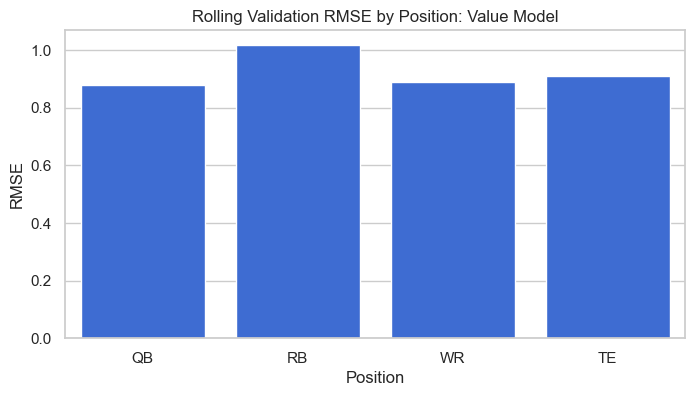

In [4]:
display(value_validation_by_position)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=value_validation_by_position,
    x="position",
    y="rmse",
    order=["QB", "RB", "WR", "TE"],
    color="#2563EB"
)
plt.title("Rolling Validation RMSE by Position: Value Model")
plt.xlabel("Position")
plt.ylabel("RMSE")
plt.show()


## Prediction Interval Calibration

The prediction interval is approximate. It combines historical rolling-validation error with disagreement across Random Forest trees.

The target is a central 80% interval. If historical coverage is much lower than 80%, the model is overconfident. If it is much higher, the intervals may be too wide to be useful.


,segment,segment_value,validation_rows,coverage_rate,mean_interval_width,mean_uncertainty,mae,rmse,target_coverage,coverage_gap
0,overall,all,1773,0.838691,2.377491,0.928707,0.675382,0.924638,0.8,0.038691
1,position,QB,208,0.817308,2.425743,0.947556,0.666787,0.876841,0.8,0.017308
2,position,RB,444,0.817568,2.377643,0.928767,0.734318,1.017201,0.8,0.017568
3,position,TE,392,0.846939,2.335712,0.912388,0.654348,0.907818,0.8,0.046939
4,position,WR,729,0.853224,2.386096,0.932069,0.653249,0.886918,0.8,0.053224


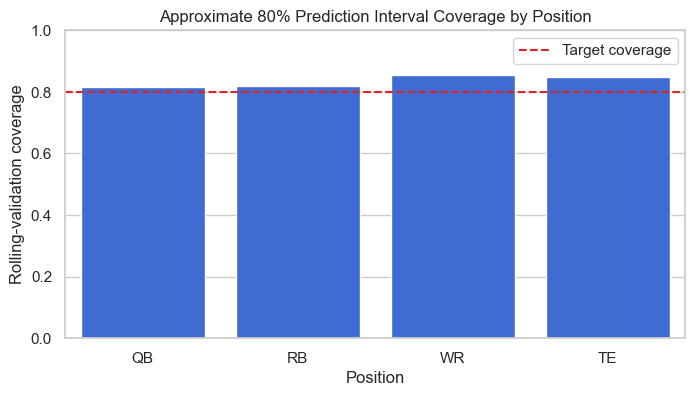

In [5]:
display(interval_validation)

plot_df = interval_validation[interval_validation["segment"].eq("position")].copy()

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="segment_value",
    y="coverage_rate",
    order=["QB", "RB", "WR", "TE"],
    color="#2563EB"
)
plt.axhline(0.80, color="#DC2626", linestyle="--", label="Target coverage")
plt.ylim(0, 1)
plt.title("Approximate 80% Prediction Interval Coverage by Position")
plt.xlabel("Position")
plt.ylabel("Rolling-validation coverage")
plt.legend()
plt.show()


## Availability Model Performance

The availability model estimates whether a player will have a qualifying next-season row. I include this because missing the next season is a real outcome, not just a data inconvenience.

This helps keep availability risk visible instead of hiding it inside the value prediction.


,accuracy,brier_score,positive_rate,roc_auc,valid_year
0,0.703704,0.189278,0.724280,0.758989,2020
1,0.703407,0.185390,0.721443,0.784572,2021
2,0.724846,0.184211,0.702259,0.777737,2022
3,0.723176,0.168431,0.751073,0.827685,2023
4,0.695378,0.178887,0.775210,0.797533,2024


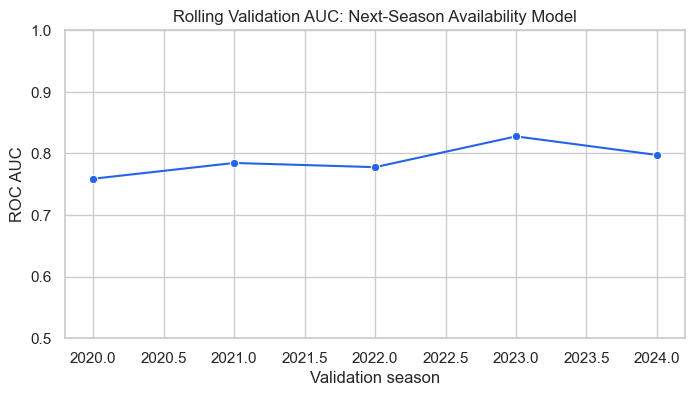

In [6]:
display(availability_metrics)

plt.figure(figsize=(8, 4))
sns.lineplot(
    data=availability_metrics,
    x="valid_year",
    y="roc_auc",
    marker="o",
    color="#2563EB"
)
plt.ylim(0.5, 1.0)
plt.title("Rolling Validation AUC: Next-Season Availability Model")
plt.xlabel("Validation season")
plt.ylabel("ROC AUC")
plt.show()

## Confidence and Risk Labels

I keep confidence and availability risk separate.

- `availability_risk_level` is about whether the player is likely to qualify next season.
- `confidence_level` is about how stable the projection looks.
- `prediction_driver` gives a short plain-English reason for the projection.

This makes the report easier to read because not every risk gets compressed into one score.


,availability_risk_level,confidence_level,players
0,High,High,23
1,High,Low,56
2,High,Medium,163
3,Low,High,13
4,Low,Low,6
5,Low,Medium,137
6,Medium,High,24
7,Medium,Low,28
8,Medium,Medium,55


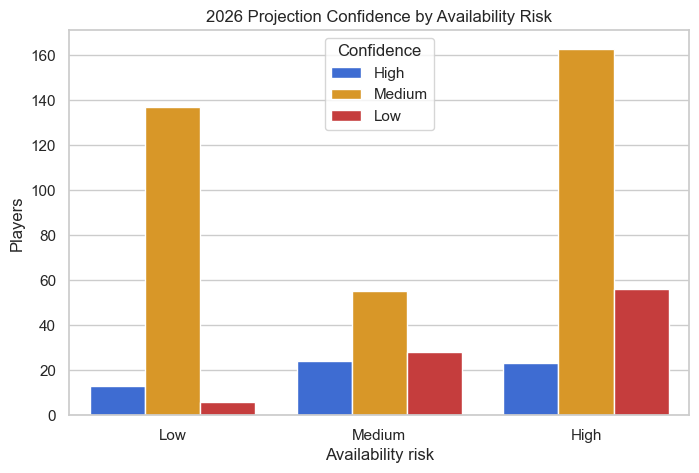

In [7]:
summary_counts = (
    player_predictions
    .groupby(["availability_risk_level", "confidence_level"], as_index=False)
    .agg(players=("player_id", "count"))
)

display(summary_counts)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=player_predictions,
    x="availability_risk_level",
    hue="confidence_level",
    order=["Low", "Medium", "High"],
    hue_order=["High", "Medium", "Low"],
    palette={"High": "#2563EB", "Medium": "#F59E0B", "Low": "#DC2626"}
)
plt.title("2026 Projection Confidence by Availability Risk")
plt.xlabel("Availability risk")
plt.ylabel("Players")
plt.legend(title="Confidence")
plt.show()

## Team and Position Views

The team field is `primary_team_2025`, meaning the team with the largest 2025 sample in the data. It should not be read as a guaranteed 2026 roster projection.

These summary views are meant for filtering and quick review, not for making team-level roster claims.


In [8]:
display(team_summary.head(15))
display(position_summary)

,primary_team_2025,players,avg_predicted_2026_value_score,avg_availability_adjusted_2026_value,avg_qualifying_probability,median_predicted_2026_value_score,avg_confidence_score,high_confidence_players,high_availability_risk_players,elite_or_above_avg_players,top_projected_player,top_projected_value_score
10,DET,15,0.405284,0.410249,0.550861,0.137900,51.473333,0,7,7,Amon-Ra St. Brown,2.345643
3,BUF,15,0.215211,0.210814,0.685789,0.035108,52.520000,0,6,5,Josh Allen,2.073380
28,SF,14,0.186566,0.142134,0.600601,-0.013160,53.214286,1,3,5,George Kittle,2.301132
11,GB,16,0.185527,0.169633,0.668450,0.152642,53.775000,4,5,8,Tucker Kraft,1.097937
5,CHI,14,0.183926,0.197563,0.664913,0.086735,56.078571,2,6,7,Colston Loveland,1.133519
21,NE,16,0.136920,0.165522,0.606818,0.017461,52.293750,0,6,5,Stefon Diggs,0.936008
15,KC,13,0.122977,0.133610,0.637274,0.021889,55.738462,2,4,5,Travis Kelce,1.106502
16,LA,14,0.112700,0.121652,0.687467,-0.087147,60.542857,3,5,4,Puka Nacua,1.630139
2,BAL,16,0.112272,0.129948,0.571221,0.006016,52.550000,2,9,6,Zay Flowers,1.213900
6,CIN,15,0.080310,0.139588,0.563978,-0.067586,54.966667,2,9,3,Ja'Marr Chase,1.922405


,position,players,avg_predicted_2026_value_score,avg_availability_adjusted_2026_value,avg_qualifying_probability,median_predicted_2026_value_score,avg_confidence_score,high_confidence_players,high_availability_risk_players,low_confidence_players,top_projected_player,top_projected_value_score
0,QB,62,0.121127,0.183935,0.573578,-0.137237,44.938710,0,30,30,Josh Allen,2.073380
3,WR,206,0.012870,0.098272,0.581766,-0.164378,56.928155,28,95,23,Amon-Ra St. Brown,2.345643
1,RB,127,-0.018140,-0.011316,0.557265,-0.004887,55.970079,12,64,24,Jahmyr Gibbs,0.555767
2,TE,110,-0.028103,0.048181,0.566462,-0.153948,59.182727,20,53,13,George Kittle,2.301132


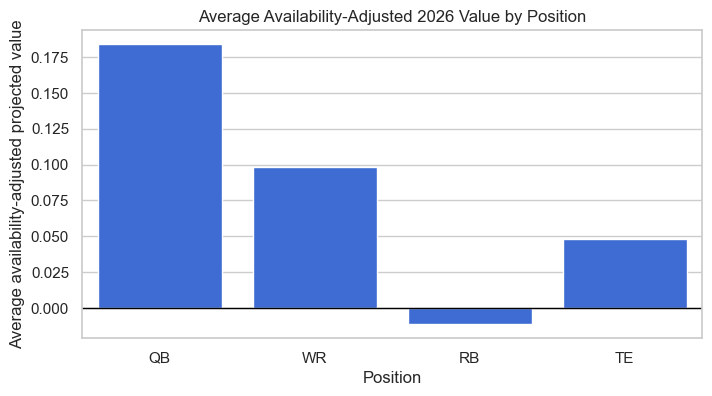

In [9]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=position_summary,
    x="position",
    y="avg_availability_adjusted_2026_value",
    color="#2563EB"
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Average Availability-Adjusted 2026 Value by Position")
plt.xlabel("Position")
plt.ylabel("Average availability-adjusted projected value")
plt.show()

## Exported Files

This notebook saves the files that support the Excel report: player predictions, team and position summaries, validation tables, model notes, and the data dictionary.

The Excel workbook is the cleanest artifact for a reviewer, while the CSVs and JSON files make the report auditable.


In [10]:
for path in sorted(output_dir.glob("2026_*")):
    print(path)

/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_availability_validation_metrics.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_availability_validation_predictions.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_low_confidence_predictions.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_player_value_predictions.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_player_value_predictions.xlsx
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_position_summary.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_prediction_data_dictionary.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_prediction_interval_validation.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/2026_prediction_model_notes.json
/Users/kylelevesque/Desktop/nfl-pla

## Methodological Notes

This report is a screening and prioritization tool, not a guarantee. That is okay for this problem. Sports forecasting is hard, so a good report should show expected value, uncertainty, and risk rather than pretending to be exact.

This version is stronger because it uses multi-year history, a depth-limited model selected with time-aware validation, traded-player aggregation before filtering, position-level validation, prediction interval calibration, and a separate availability model.

Important limitations remain:

- It does not know future injuries, depth-chart changes, coaching changes, rookies, free agency, or 2026 team context.
- EPA-based production reflects team environment and usage, not pure individual talent.
- The model is pooled across positions, so position-level validation is a check, not a complete replacement for position-specific models.
- `predicted_2026_value_score`, qualifying probability, prediction interval, and driver notes should be interpreted together.
